<a href="https://colab.research.google.com/github/subudhi-ms/AML-LAB/blob/main/AS%209/ROC_curve_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Threshold  | Precision  | tpr          | fpr       
---------------------------------------------
0.2        | 0.5        | 1.0          | 1.0       
0.4        | 0.7        | 1.0          | 0.5       
0.6        | 1.0        | 1.0          | 0.0       
0.9        | 1.0        | 0.5          | 0.0       
1.0        | nan        | 0.0          | 0.0       


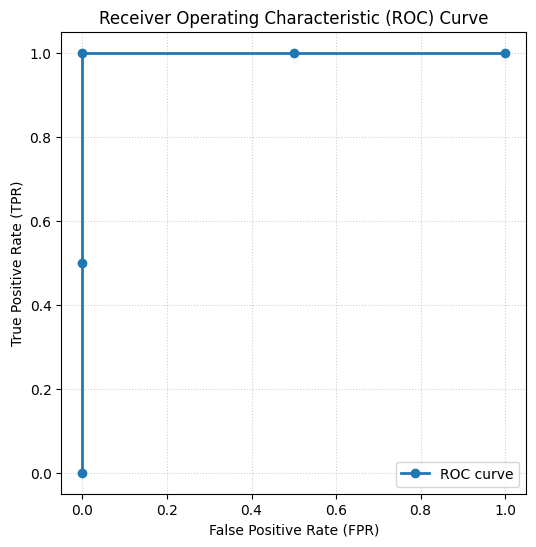

In [3]:
import numpy as np
import matplotlib.pyplot as plt


actual = np.array([1, 1, 0, 0])
prob = np.array([0.9, 0.6, 0.4, 0.2])
fpr_list = []
tpr_list = []
thresholds = [0.2, 0.4, 0.6, 0.9, 1.0]
print(f"{"Threshold":<10} | {"Precision":<10} | {"tpr":<12} | {"fpr":<10}")
print("-" * 45)
for i in thresholds:
  pred = prob >= i
  tp = ((actual == 1) & (pred == True)).sum()
  fp = ((actual == 0) & (pred == True)).sum()
  tn = ((actual == 0) & (pred == False)).sum()
  fn = ((actual == 1) & (pred == False)).sum()
  precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

  tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
  fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

  print(f"{i:<10} | {precision:<10.1f} | {tpr:<12} | {fpr:<10}")
  fpr_list.append(fpr)
  tpr_list.append(tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr_list, tpr_list, lw=2, marker='o', label='ROC curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()